# Import library

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

import os
import matplotlib.pyplot as plt
import datetime as dt

from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Set Random Seed

In [2]:
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)


# Global variables

In [3]:
EPOCHS = 100
BATCH_SIZE = 8
WINDOW = 5
HORIZON = 1
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.5


# Load data

In [4]:
AAPL = pd.read_csv('./Dataset_A/AAPL.csv', parse_dates=True)

AAPL['Date'] = pd.to_datetime(AAPL['Date'])
AAPL.set_index('Date', inplace=True)

# EDA

In [5]:
AAPL.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


<Axes: xlabel='Date'>

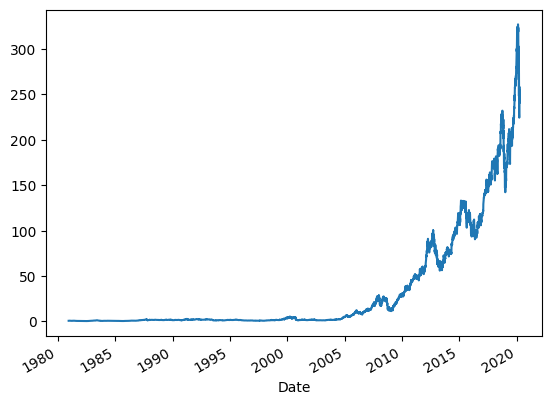

In [6]:
AAPL['Close'].plot()

In [7]:
AAPL['Close'].describe()

count    9909.000000
mean       32.618030
std        58.471899
min         0.196429
25%         1.071429
50%         1.732143
75%        35.761429
max       327.200012
Name: Close, dtype: float64

## Visualize Data as Time Series

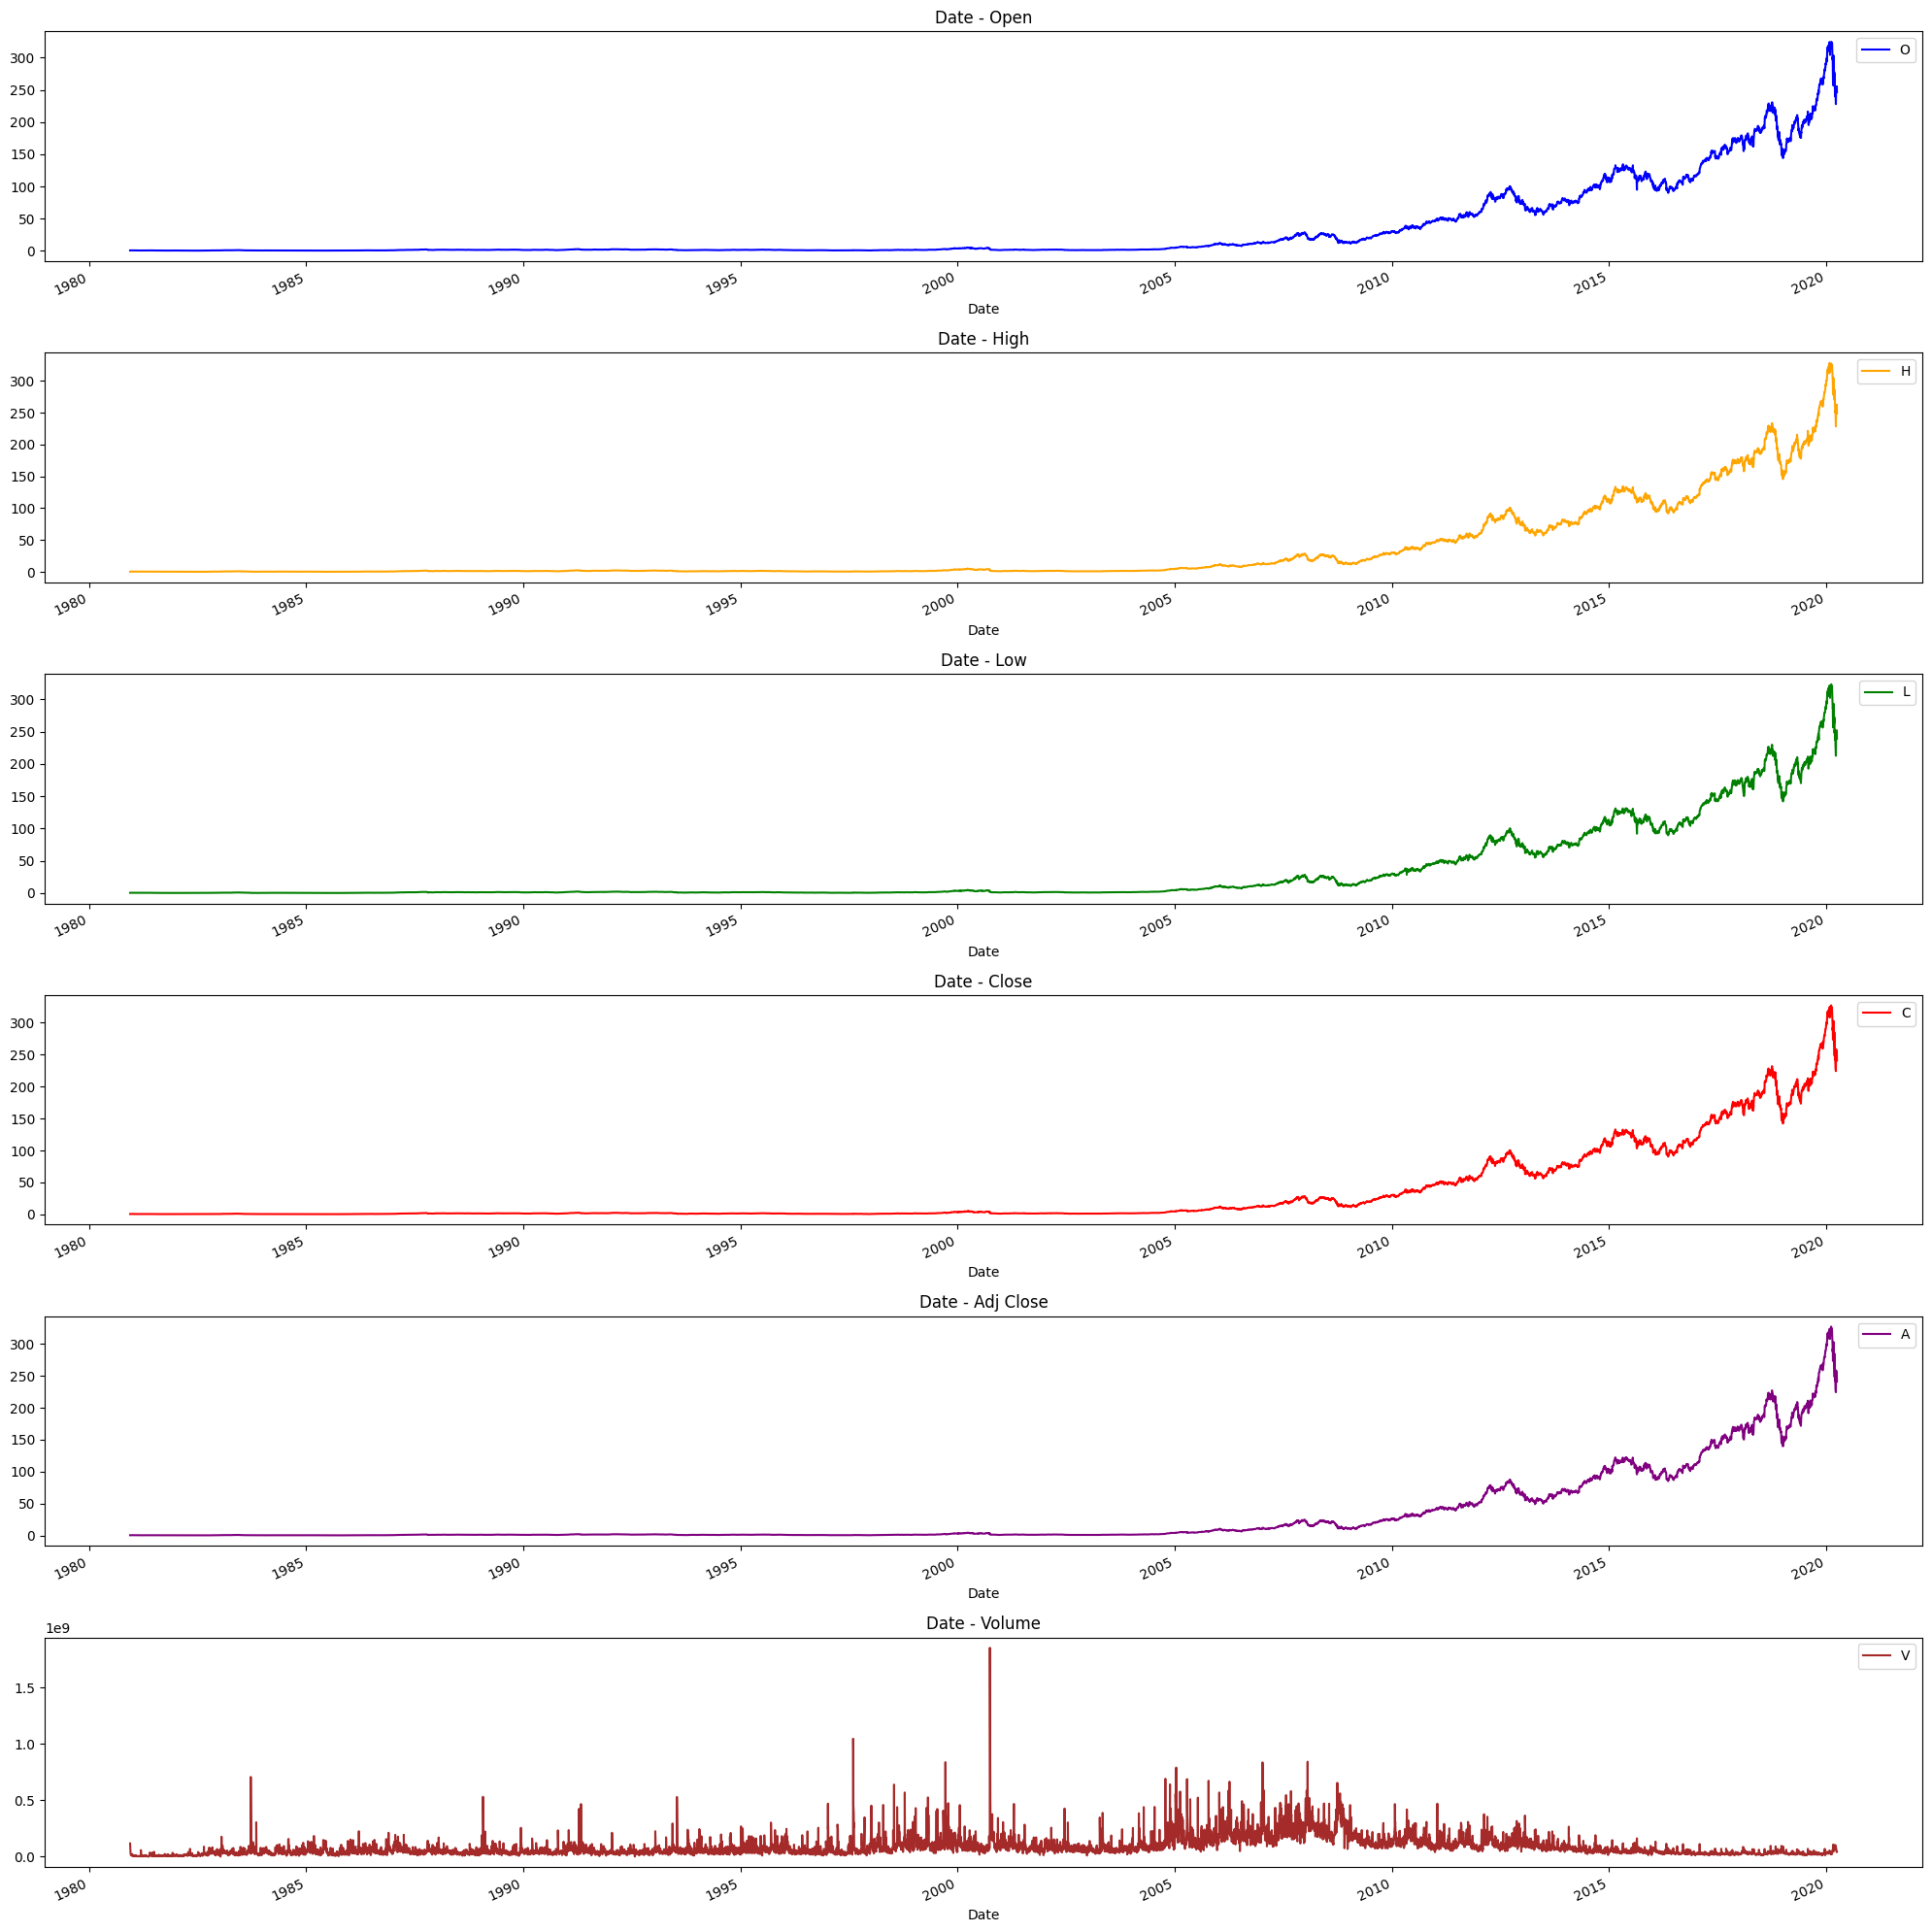

In [8]:
COLORS = ["blue", "orange", "green", "red", "purple", "brown", "pink", "gray", "olive", "cyan"]

def create_vizualizations(data : pd.DataFrame):
    columns = list(data.columns)
    x = data.index
    fig, axes = plt.subplots(nrows=len(columns), ncols=1, figsize=(20, 20), facecolor='w', edgecolor='k')
    for idx, col in enumerate(columns):
        ax = data[col].plot(ax=axes[idx], color=COLORS[idx], title=f'{x.name} - {col}', rot=25)
        ax.legend(col)
    plt.tight_layout()

create_vizualizations(AAPL)

## Missing Values

In [9]:
AAPL.isna().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

# Preprocessing

## Drop Unnecessary Columns

In [10]:
AAPL_close = AAPL.copy()[['Close']]
AAPL_close.head()

,Close
Date,
1980-12-12,0.513393
1980-12-15,0.486607
1980-12-16,0.450893
1980-12-17,0.462054
1980-12-18,0.475446


## Data Normalization

In [11]:
data = AAPL_close.values.tolist()

class normalize:
    def __init__(self, data):
        self.data = np.array(data, dtype='float32')
        self.mean = self.data.mean(axis=0)
        self.std = self.data.std(axis=0)
    
    def __call__(self):
        return list((self.data - self.mean)/self.std)
    
    def inverse(self, data):
        return list(data*self.std + self.mean)

normalizer = normalize(data)

In [12]:
data = normalizer()

## Create TimeSeries Instances

In [13]:
def create_instances(data, window : int = 1, future : int = 1):
    X, y = [], []
    for i in range(len(data)-window-future):
        feature = data[i : i+window]
        # target = data[i+future+1 : i+window+future+1]
        target = data[i+window+future]
        X.append(feature)
        y.append(target)
    return X, y

In [14]:
X, y = create_instances(data, window=WINDOW, future=HORIZON)

## Split Data (Train, Validation, Test)

In [15]:
# Split the data with 80% for training and 10% for validation and 10% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SPLIT, shuffle=False, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, train_size=VAL_SPLIT, shuffle=False, random_state=42)

## Convert Data to Tensor Slices

In [16]:
# Convert the data to tensors and create dataloaders

X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

X_val = tf.convert_to_tensor(X_val, dtype=tf.float32)
y_val = tf.convert_to_tensor(y_val, dtype=tf.float32)

X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

train_data = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE)
val_data = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_data = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

# Base Model (LSTM)

## Define Model Architecture

In [17]:
def create_model(time_steps, num_features):
    i = Input(shape=(time_steps, num_features))
    x = LSTM(units=50, activation='relu')(i)
    x = Dense(1)(x)
    model = Model(inputs=i, outputs=x)
    return model

In [18]:
base_model = create_model(WINDOW, 1)

In [19]:
base_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 5, 1)]            0         
                                                                 
 lstm (LSTM)                 (None, 50)                10400     
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 10,451
Trainable params: 10,451
Non-trainable params: 0
_________________________________________________________________


## Compile Model

In [20]:
base_model.compile(optimizer=Adam(), loss='mae', metrics=[RootMeanSquaredError(), 'mae', MeanAbsolutePercentageError()])

## Train Model

In [21]:
checkpointer = ModelCheckpoint(filepath = './exp/AAPL/weights_best.hdf5', verbose = 1, save_best_only = True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)

his_baseModel=base_model.fit(train_data, 
               epochs=EPOCHS, 
               validation_data=val_data, 
               batch_size=BATCH_SIZE, 
               callbacks=[checkpointer, early_stopping])

Epoch 1/100
991/991 [==============================] - ETA: 0s - loss: 0.0415 - root_mean_squared_error: 0.1184 - mae: 0.0415 - mean_absolute_percentage_error: 33.4474
Epoch 1: val_loss improved from inf to 0.12026, saving model to ./exp/AAPL\weights_best.hdf5
991/991 [==============================] - 18s 16ms/step - loss: 0.0415 - root_mean_squared_error: 0.1184 - mae: 0.0415 - mean_absolute_percentage_error: 33.4474 - val_loss: 0.1203 - val_root_mean_squared_error: 0.1316 - val_mae: 0.1203 - val_mean_absolute_percentage_error: 13.2355
Epoch 2/100
988/991 [============================>.] - ETA: 0s - loss: 0.0178 - root_mean_squared_error: 0.0586 - mae: 0.0178 - mean_absolute_percentage_error: 7.9517
Epoch 2: val_loss improved from 0.12026 to 0.05063, saving model to ./exp/AAPL\weights_best.hdf5
991/991 [==============================] - 17s 17ms/step - loss: 0.0180 - root_mean_squared_error: 0.0588 - mae: 0.0180 - mean_absolute_percentage_error: 7.9643 - val_loss: 0.0506 - val_root_m

## Evaluate Model

In [22]:
def real_loss(history):
    best_val_loss = min(history.history['val_loss'])
    best_loss = min(history.history['loss'])
    
    best_MAPE = min(history.history['val_mean_absolute_percentage_error'])
    return normalizer.inverse(best_val_loss), normalizer.inverse(best_loss), best_MAPE

print('Best Validation Loss (MAE): ', real_loss(his_baseModel)[0])
print('Best Training Loss (MAE): ', real_loss(his_baseModel)[1])
print('Best MAPE: ', real_loss(his_baseModel)[2])

Best Validation Loss (MAE):  [35.578487]
Best Training Loss (MAE):  [33.07739]
Best MAPE:  5.842737197875977


There's a average absolute deviation of 36 and MAPE of 7% on the validation set. This can be intrepreted that the model prediction of the stock price have an average of 4% deviation or 36 dollar. which is not bad for a simple LSTM model. but maybe we can improve it by using a more complex model.

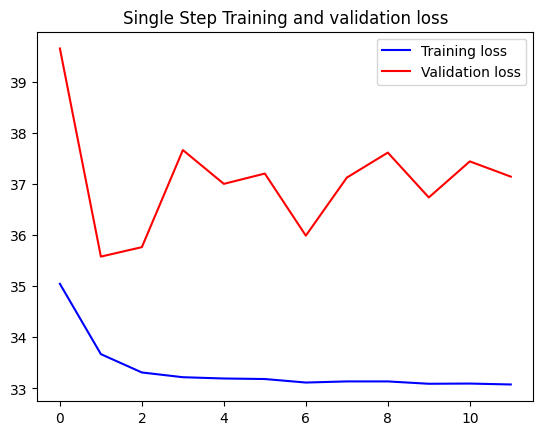

In [23]:
def plot_train_history(history, title):
    loss = normalizer.inverse(history.history['loss'])
    val_loss = normalizer.inverse(history.history['val_loss'])

    epochs = range(len(loss))

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.legend()

    plt.show()
    
plot_train_history(his_baseModel, 'Single Step Training and validation loss')

The model is overfitting as the validation loss and train loss has such a large difference.